**Classes:** PartDrawing / Table / Note  
**Model:** Faster R-CNN R50-FPN  
**Split:** 80% Train / 10% Val / 10% Test  

In [1]:
import os 
import subprocess
import torch

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')

major, minor = torch.cuda.get_device_capability(0)
print(f'GPU arch: sm_{major}{minor}')

arch_list = f'{major}.{minor}' 

os.environ['TORCH_CUDA_ARCH_LIST'] = arch_list
os.environ['FORCE_CUDA'] = '1'

result = subprocess.run(
    ['pip', 'install', 'git+https://github.com/facebookresearch/detectron2.git',
     '--quiet', '--no-build-isolation'],
    capture_output=True, text=True, env={**os.environ}
)
print(result.stdout[-500:] if result.stdout else '')
print(result.stderr[-300:] if result.returncode != 0 else 'Detectron2 installed OK')

PyTorch : 2.10.0+cu128
CUDA    : 12.8
GPU arch: sm_75
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 5.8 MB/s eta 0:00:00

Detectron2 installed OK


In [2]:
import os
import json
import random
import xml.etree.ElementTree as ET
from collections import Counter
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.model_selection import train_test_split

import torch
import detectron2
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.data.datasets import register_coco_instances
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
from detectron2.utils.visualizer import Visualizer, ColorMode

import shutil

print(f'Detectron2 : {detectron2.__version__}')
print(f'GPU        : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}')

Detectron2 : 0.6
GPU        : Tesla T4


In [ ]:
INPUT_DIR = f'/kaggle/input/datasets/shiinas2/segmentation-data/BOM-Dataset-20260330T083420Z-1-001/'
IMAGE_DIR = os.path.join(INPUT_DIR, 'BOM-Dataset')

INPUT_DIR_SEG = '/kaggle/input/datasets/shiinas2/segmentation-data/data_segmentation'
ANNOTATION_XML = os.path.join(INPUT_DIR_SEG, 'annotations.xml') 

WORK_DIR       = '/kaggle/working'                          
COCO_JSON_DIR  = os.path.join(WORK_DIR, 'coco_json')
OUTPUT_DIR     = os.path.join(WORK_DIR, 'output')

os.makedirs(COCO_JSON_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR,    exist_ok=True)

CLASS_NAMES = ['PartDrawing', 'Table', 'Note']
CLASS_ID    = {name: idx for idx, name in enumerate(CLASS_NAMES)}

# ============================================================
# CONFIG
RANDOM_SEED = 42
TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1
TEST_RATIO  = 0.1

print('Kiểm tra')
checks = [
    ('IMAGE_DIR', IMAGE_DIR),
    ('ANNOTATION_XML', ANNOTATION_XML),
    ('COCO_JSON_DIR', COCO_JSON_DIR),
    ('OUTPUT_DIR', OUTPUT_DIR),
]
all_ok = True
for name, path in checks:
    exists = os.path.exists(path)
    status = "True" if exists else "False"
    print(f'  {name:<18}: {path}  {status}')
    if not exists and 'input' in path:
        all_ok = False

if all_ok:
    n_images = len(os.listdir(IMAGE_DIR))
    print(f'\nTổng số ảnh trong IMAGE_DIR: {n_images}')
else:
    raise("Not found")

Kiểm tra
  IMAGE_DIR         : /kaggle/input/datasets/shiinas2/segmentation-data/BOM-Dataset-20260330T083420Z-1-001/BOM-Dataset  True
  ANNOTATION_XML    : /kaggle/input/datasets/shiinas2/segmentation-data/data_segmentation/annotations.xml  True
  COCO_JSON_DIR     : /kaggle/working/coco_json  True
  OUTPUT_DIR        : /kaggle/working/output  True

Tổng số ảnh trong IMAGE_DIR: 58


In [ ]:
def parse_cvat_xml(xml_path, image_dir, class_id):
    """
    Đọc file annotations.xml định dạng CVAT 1.1.
    Trả về list records, mỗi record là 1 ảnh với danh sách bounding box.
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    dataset  = []
    skipped  = 0

    for img_elem in root.findall('image'):
        raw_name  = img_elem.attrib['name']        # vd: BOM-Dataset/1.png
        img_name  = os.path.basename(raw_name)     # vd: 1.png
        full_path = os.path.join(image_dir, img_name)

        if not os.path.exists(full_path):
            skipped += 1
            continue

        width  = int(img_elem.attrib['width'])
        height = int(img_elem.attrib['height'])
        img_id = int(img_elem.attrib['id'])

        boxes = []
        for box in img_elem.findall('box'):
            label = box.attrib['label']
            if label not in class_id:
                continue
            boxes.append({
                'bbox'       : [
                    float(box.attrib['xtl']),
                    float(box.attrib['ytl']),
                    float(box.attrib['xbr']),
                    float(box.attrib['ybr']),
                ],
                'category_id': class_id[label],
                'label'      : label,
            })

        dataset.append({
            'file_name': full_path,
            'image_id': img_id,
            'width': width,
            'height': height,
            'annotations': boxes,
        })

    print(f'Parsed: {len(dataset)} images')
    print(f'Skipped  : {skipped} images')
    total = sum(len(r["annotations"]) for r in dataset)
    print(f'Total ann: {total} bounding boxes')
    return dataset


all_records = parse_cvat_xml(ANNOTATION_XML, IMAGE_DIR, CLASS_ID)

label_count = Counter()
for rec in all_records:
    for ann in rec['annotations']:
        label_count[ann['label']] += 1

print('\nAnnotations per class:')
for cls in CLASS_NAMES:
    print(f'{cls:<14}:{label_count[cls]:>4}')

Parsed: 58 images
Skipped  : 0 images
Total ann: 366 bounding boxes

Annotations per class:
PartDrawing   : 251
Table         :  85
Note          :  30


In [ ]:
train_val, test_records = train_test_split(
    all_records,
    test_size   = TEST_RATIO,
    random_state= RANDOM_SEED
)

train_records, val_records = train_test_split(
    train_val,
    test_size   = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO),
    random_state= RANDOM_SEED
)

total = len(all_records)
print(f'Tổng: {total} ảnh')
print(f'Train: {len(train_records)} ảnh ({len(train_records)/total*100:.1f}%)')
print(f'Val: {len(val_records)} ảnh ({len(val_records)/total*100:.1f}%)')
print(f'Test: {len(test_records)} ảnh ({len(test_records)/total*100:.1f}%)')

print('\nTest images:')
for r in test_records:
    print(f'  {os.path.basename(r["file_name"])}')

Tổng: 58 ảnh
Train: 46 ảnh (79.3%)
Val: 6 ảnh (10.3%)
Test: 6 ảnh (10.3%)

Test images:
  1.png
  14.png
  40.jpg
  21.jpg
  5.jpg
  57.jpg


In [ ]:
def save_coco_json(records, output_path):
    """
    Chuyển records -> COCO JSON format và lưu file.
    COCO bbox format: [x_topleft, y_topleft, width, height]
    """
    coco = {
        'info': {'description': 'BOM Document Dataset'},
        'categories': [
            {'id': idx, 'name': name, 'supercategory': 'document'}
            for name, idx in CLASS_ID.items()
        ],
        'images': [],
        'annotations': [],
    }

    ann_id = 0
    for rec in records:
        coco['images'].append({
            'id' : rec['image_id'],
            'file_name' : rec['file_name'],
            'width' : rec['width'],
            'height' : rec['height'],
        })
        for ann in rec['annotations']:
            x1, y1, x2, y2 = ann['bbox']
            w, h = x2 - x1, y2 - y1
            coco['annotations'].append({
                'id': ann_id,
                'image_id' : rec['image_id'],
                'category_id' : ann['category_id'],
                'bbox': [x1, y1, w, h],
                'area': w * h,
                'iscrowd' : 0,
            })
            ann_id += 1

    with open(output_path, 'w') as f:
        json.dump(coco, f)

    print(f'  Saved: {output_path}')
    print(f'         {len(coco["images"])} images | {len(coco["annotations"])} annotations')


TRAIN_JSON = os.path.join(COCO_JSON_DIR, 'train.json')
VAL_JSON   = os.path.join(COCO_JSON_DIR, 'val.json')
TEST_JSON  = os.path.join(COCO_JSON_DIR, 'test.json')

print('Saving COCO JSON files...')
save_coco_json(train_records, TRAIN_JSON)
save_coco_json(val_records, VAL_JSON)
save_coco_json(test_records, TEST_JSON)

Saving COCO JSON files...
  Saved: /kaggle/working/coco_json/train.json
         46 images | 300 annotations
  Saved: /kaggle/working/coco_json/val.json
         6 images | 37 annotations
  Saved: /kaggle/working/coco_json/test.json
         6 images | 29 annotations


In [ ]:
for name in ['bom_train', 'bom_val', 'bom_test']:
    if name in DatasetCatalog.list():
        DatasetCatalog.remove(name)
        MetadataCatalog.remove(name)

#3 splits
register_coco_instances('bom_train', {}, TRAIN_JSON, IMAGE_DIR)
register_coco_instances('bom_val',   {}, VAL_JSON,   IMAGE_DIR)
register_coco_instances('bom_test',  {}, TEST_JSON,  IMAGE_DIR)

for name in ['bom_train', 'bom_val', 'bom_test']:
    MetadataCatalog.get(name).set(thing_classes=CLASS_NAMES)

meta = MetadataCatalog.get('bom_train')
print('Đã đăng ký: bom_train | bom_val | bom_test')
print(f'Classes   : {meta.thing_classes}')

Đã đăng ký: bom_train | bom_val | bom_test
Classes   : ['PartDrawing', 'Table', 'Note']


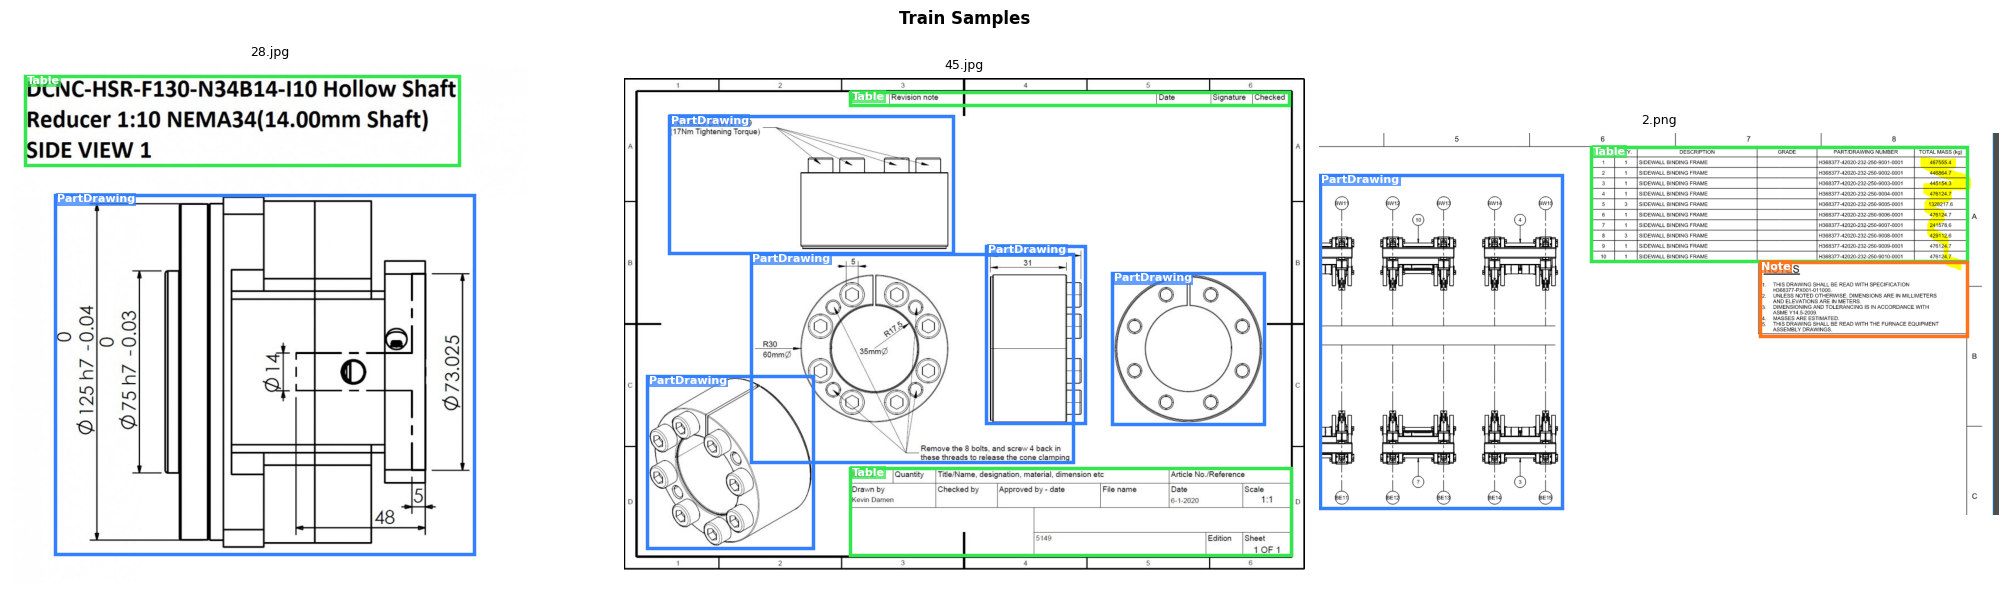

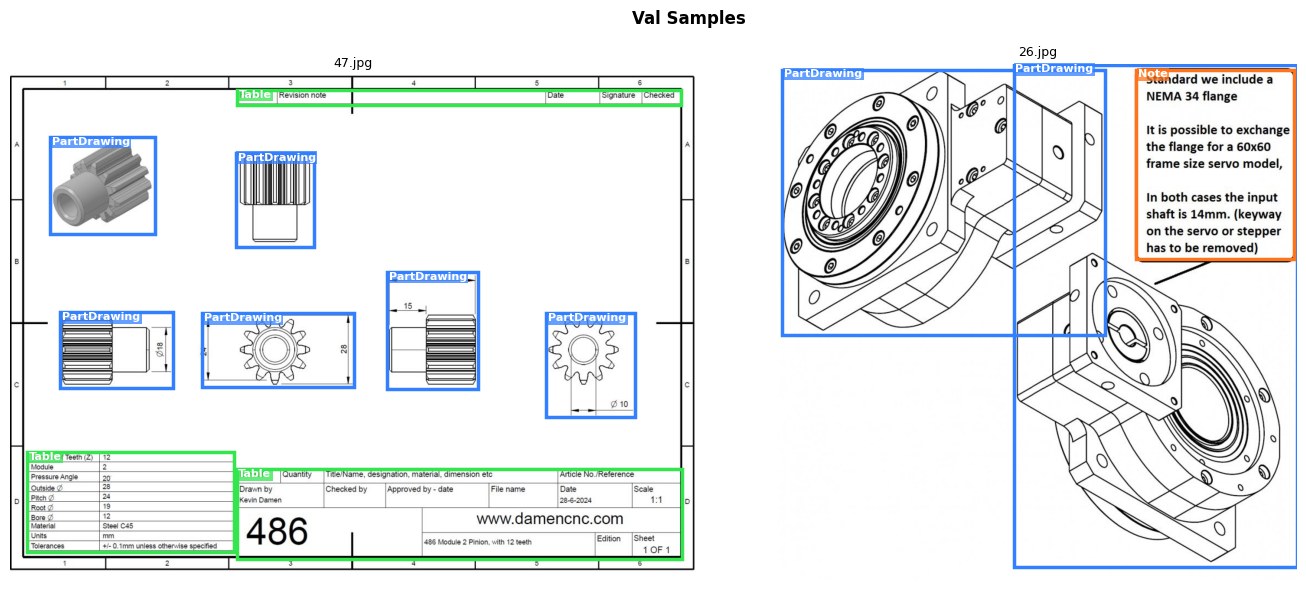

In [ ]:
COLOR_MAP = {
    'PartDrawing' : (0.2, 0.5, 1.0),
    'Table' : (0.2, 0.9, 0.3),
    'Note' : (1.0, 0.45, 0.1),
}

def show_samples(records, n=3, title=''):
    samples = random.sample(records, min(n, len(records)))
    fig, axes = plt.subplots(1, len(samples), figsize=(7 * len(samples), 6))
    if len(samples) == 1:
        axes = [axes]

    for ax, rec in zip(axes, samples):
        img = cv2.cvtColor(cv2.imread(rec['file_name']), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(os.path.basename(rec['file_name']), fontsize=9)
        ax.axis('off')
        for ann in rec['annotations']:
            x1, y1, x2, y2 = ann['bbox']
            color = COLOR_MAP.get(ann['label'], (1, 1, 0))
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2.5, edgecolor=color, facecolor='none'
            ))
            ax.text(x1 + 3, y1 + 14, ann['label'],
                    color='white', fontsize=8, fontweight='bold',
                    bbox=dict(facecolor=color, alpha=0.75, pad=1, linewidth=0))

    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


show_samples(train_records, n=3, title='Train Samples')
show_samples(val_records,   n=2, title='Val Samples  ')

In [ ]:
cfg = get_cfg()

# ─────────────────────────────────────────────────────────────
#  MODEL: Faster R-CNN + ResNet-50 + FPN
#  Pretrained trên COCO -> fine-tune trên BOM dataset
# ─────────────────────────────────────────────────────────────
cfg.merge_from_file(model_zoo.get_config_file(
    'COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml'
))
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    'COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml'
)


cfg.DATASETS.TRAIN = ('bom_train',)
cfg.DATASETS.TEST  = ('bom_val',) 


cfg.DATALOADER.NUM_WORKERS = 2

#  CONFIG TRAINING 
cfg.SOLVER.IMS_PER_BATCH    = 2       # Batch size
cfg.SOLVER.BASE_LR          = 0.00025
cfg.SOLVER.MAX_ITER         = 12000  
cfg.SOLVER.STEPS            = (2000, 2500)
cfg.SOLVER.GAMMA            = 0.1
cfg.SOLVER.WARMUP_ITERS     = 200
cfg.SOLVER.WARMUP_METHOD    = 'linear'
cfg.SOLVER.CHECKPOINT_PERIOD= 500


cfg.TEST.EVAL_PERIOD = 500 # Eval trên val mỗi 500 iters

#  MODEL HEAD
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES          = len(CLASS_NAMES)  # 3
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST    = 0.5

cfg.OUTPUT_DIR    = OUTPUT_DIR
cfg.MODEL.DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

print('TRAINING CONFIG')
print(f'Backbone     : ResNet-50 + FPN')
print(f'Pretrain     : COCO (transfer learning)')
print(f'Num classes  : {cfg.MODEL.ROI_HEADS.NUM_CLASSES}  {CLASS_NAMES}')
print(f'Batch size   : {cfg.SOLVER.IMS_PER_BATCH}')
print(f'Learning rate: {cfg.SOLVER.BASE_LR}')
print(f'Max iters    : {cfg.SOLVER.MAX_ITER}')
print(f'LR decay at  : {cfg.SOLVER.STEPS}')
print(f'Eval every   : {cfg.TEST.EVAL_PERIOD} iters')
print(f'Device       : {cfg.MODEL.DEVICE}')
print(f'Output       : {cfg.OUTPUT_DIR}')

TRAINING CONFIG
Backbone     : ResNet-50 + FPN
Pretrain     : COCO (transfer learning)
Num classes  : 3  ['PartDrawing', 'Table', 'Note']
Batch size   : 2
Learning rate: 0.00025
Max iters    : 12000
LR decay at  : (2000, 2500)
Eval every   : 500 iters
Device       : cuda
Output       : /kaggle/working/output


In [ ]:
import logging
from detectron2.utils.logger import setup_logger

logging.basicConfig(level=logging.WARNING)
setup_logger(name="fvcore")
setup_logger(name="detectron2")

from detectron2.engine import HookBase
from detectron2.utils.events import JSONWriter, TensorboardXWriter

class SimplePrintHook(HookBase):
    def after_step(self):
        iter_num = self.trainer.iter
        max_iter = self.trainer.max_iter
        
        if iter_num % 50 == 0 or iter_num == max_iter - 1:
            try:
                loss = self.trainer.storage.history('total_loss').latest()
                lr = self.trainer.storage.history('lr').latest()
                print(f"👉 Iteration {iter_num}/{max_iter} | Loss: {loss:.4f} | LR: {lr:.6f}")
            except KeyError:
                pass

class BOMTrainer(DefaultTrainer):

    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, 'val_eval')
        os.makedirs(output_folder, exist_ok=True)
        return COCOEvaluator(
            dataset_name = dataset_name,
            output_dir = output_folder,
            tasks = ('bbox',),
        )

    def build_writers(self):
        return [
            JSONWriter(os.path.join(self.cfg.OUTPUT_DIR, "metrics.json")),
            TensorboardXWriter(self.cfg.OUTPUT_DIR),
        ]


In [ ]:
trainer = BOMTrainer(cfg)
trainer.resume_or_load(resume=False)

trainer.register_hooks([SimplePrintHook()])

print(f'- Train: {len(train_records)} ảnh | Val: {len(val_records)} ảnh')
print(f'- Max iterations: {cfg.SOLVER.MAX_ITER}')
print()

trainer.train()

print('Done')
print(f'Model lưu tại: {OUTPUT_DIR}/model_final.pth')


[04/02 19:11:48 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

model_final_280758.pkl: 167MB [00:00, 186MB/s]                           

[04/02 19:11:49 fvcore.common.checkpoint]: [Checkpointer] Loading from /root/.torch/iopath_cache/detectron2/COCO-Detection/faster_rcnn_R_50_FPN_3x/137849458/model_final_280758.pkl ...


[04/02 19:11:49 fvcore.common.checkpoint]: Reading a file from 'Detectron2 Model Zoo'
WARNING [04/02 19:11:49 fvcore.common.checkpoint]: Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (4, 1024) in the model! You might want to double check if this is expected.
WARNING [04/02 19:11:49 fvcore.common.checkpoint]: Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (4,) in the model! You might want to double check if this is expected.
WARNING [04/02 19:11:49 fvcore.common.checkpoint]: Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (12, 1024) in the model! You might want to double check if this is expected.
WARNING [04/02 19:11:49 fvcore.common.checkpoint]: Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the m

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0402 19:11:52.659000 24 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Iteration 0/12000 | Loss: 6.4733 | LR: 0.000000


2026-04-02 19:12:02.762225: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775157122.955939      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775157123.012775      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775157123.508821      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775157123.508865      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775157123.508867      24 computation_placer.cc:177] computation placer alr

Iteration 50/12000 | Loss: 1.8680 | LR: 0.000063
Iteration 100/12000 | Loss: 1.4345 | LR: 0.000125
Iteration 150/12000 | Loss: 1.2400 | LR: 0.000188
Iteration 200/12000 | Loss: 0.8081 | LR: 0.000250
Iteration 250/12000 | Loss: 1.2180 | LR: 0.000250
Iteration 300/12000 | Loss: 0.5061 | LR: 0.000250
Iteration 350/12000 | Loss: 0.8076 | LR: 0.000250
Iteration 400/12000 | Loss: 0.5388 | LR: 0.000250
Iteration 450/12000 | Loss: 0.4852 | LR: 0.000250
[04/02 19:15:53 fvcore.common.checkpoint]: Saving checkpoint to /kaggle/working/output/model_0000499.pth
WARNING [04/02 19:15:53 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[04/02 19:15:53 d2.data.datasets.coco]: Loaded 6 images in COCO format from /kaggle/working/coco_json/val.json
[04/02 19:15:53 d2.data.build]: Distribution of instances among all 3 categories:
|  category   | #instances   |  category  | #instances   |  category  | #instances   |
|:-----------:|:------------

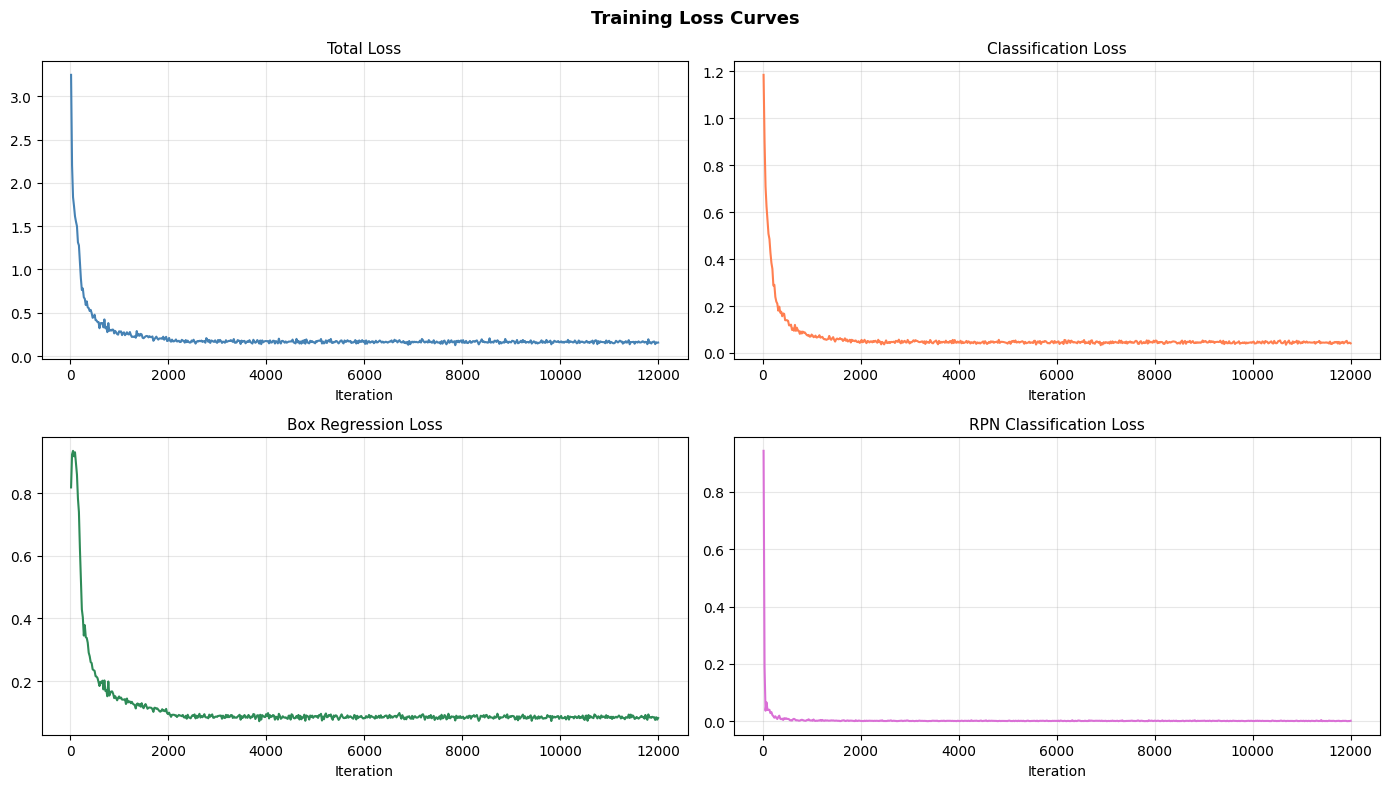

Saved: loss_curves.png


In [ ]:
metrics_path = Path(OUTPUT_DIR) / 'metrics.json'

if not metrics_path.exists():
    print('Chưa có metrics.json.')
else:
    logs = []
    with open(metrics_path) as f:
        for line in f:
            try:
                logs.append(json.loads(line.strip()))
            except:
                pass

    train_logs = [r for r in logs if 'total_loss' in r]

    iters      = [r['iteration']        for r in train_logs]
    total_loss = [r['total_loss']        for r in train_logs]
    cls_loss   = [r.get('loss_cls', 0)  for r in train_logs]
    box_loss   = [r.get('loss_box_reg', 0) for r in train_logs]
    rpn_loss   = [r.get('loss_rpn_cls', 0) for r in train_logs]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    plot_data = [
        (axes[0, 0], iters, total_loss,'Total Loss','steelblue'),
        (axes[0, 1], iters, cls_loss,'Classification Loss','coral'),
        (axes[1, 0], iters, box_loss,'Box Regression Loss','seagreen'),
        (axes[1, 1], iters, rpn_loss,'RPN Classification Loss','orchid'),
    ]
    for ax, x, y, title, color in plot_data:
        ax.plot(x, y, color=color, linewidth=1.5)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Iteration')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Training Loss Curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'loss_curves.png'), dpi=120)
    plt.show()
    print('Saved: loss_curves.png')

In [ ]:
cfg.MODEL.WEIGHTS = os.path.join(OUTPUT_DIR, 'model_final.pth')
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  

predictor = DefaultPredictor(cfg)

test_output_folder = os.path.join(OUTPUT_DIR, 'test_eval')
os.makedirs(test_output_folder, exist_ok=True)

evaluator   = COCOEvaluator('bom_test', output_dir=test_output_folder, tasks=('bbox',))
test_loader = build_detection_test_loader(cfg, 'bom_test')

print('Evaluation trên Test set')
results = inference_on_dataset(predictor.model, test_loader, evaluator)

bbox_res = results.get('bbox', {})
print()
print('TEST SET RESULTS')
key_metrics = [
    ('AP',    'mAP@0.5:0.95 (COCO)'),
    ('AP50',  'mAP@0.5 ← main metric'),
    ('AP75',  'mAP@0.75     (stricter)'),
]
for key, desc in key_metrics:
    val = bbox_res.get(key, -1)
    print(f'  {key:<8}: {val:6.2f}   ({desc})')
print('=' * 45)

ap50 = bbox_res.get('AP50', 0)
if ap50 >= 80:
    grade = 'Tốt'
elif ap50 >= 60:
    grade = 'Khá'
elif ap50 >= 40:
    grade = 'Trung bình'
else:
    grade = 'Cần cải thiện'
print(f'\nĐánh giá tổng thể: {grade}  (mAP@0.5 = {ap50:.1f})')

[04/02 20:45:39 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/output/model_final.pth ...
[04/02 20:45:39 fvcore.common.checkpoint]: [Checkpointer] Loading from /kaggle/working/output/model_final.pth ...
WARNING [04/02 20:45:39 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[04/02 20:45:39 d2.data.datasets.coco]: Loaded 6 images in COCO format from /kaggle/working/coco_json/test.json
[04/02 20:45:39 d2.data.build]: Distribution of instances among all 3 categories:
|  category   | #instances   |  category  | #instances   |  category  | #instances   |
|:-----------:|:-------------|:----------:|:-------------|:----------:|:-------------|
| PartDrawing | 17           |   Table    | 8            |    Note    | 4            |
|             |              |            |              |            |              |
|    total    | 29           |            |              |            |  

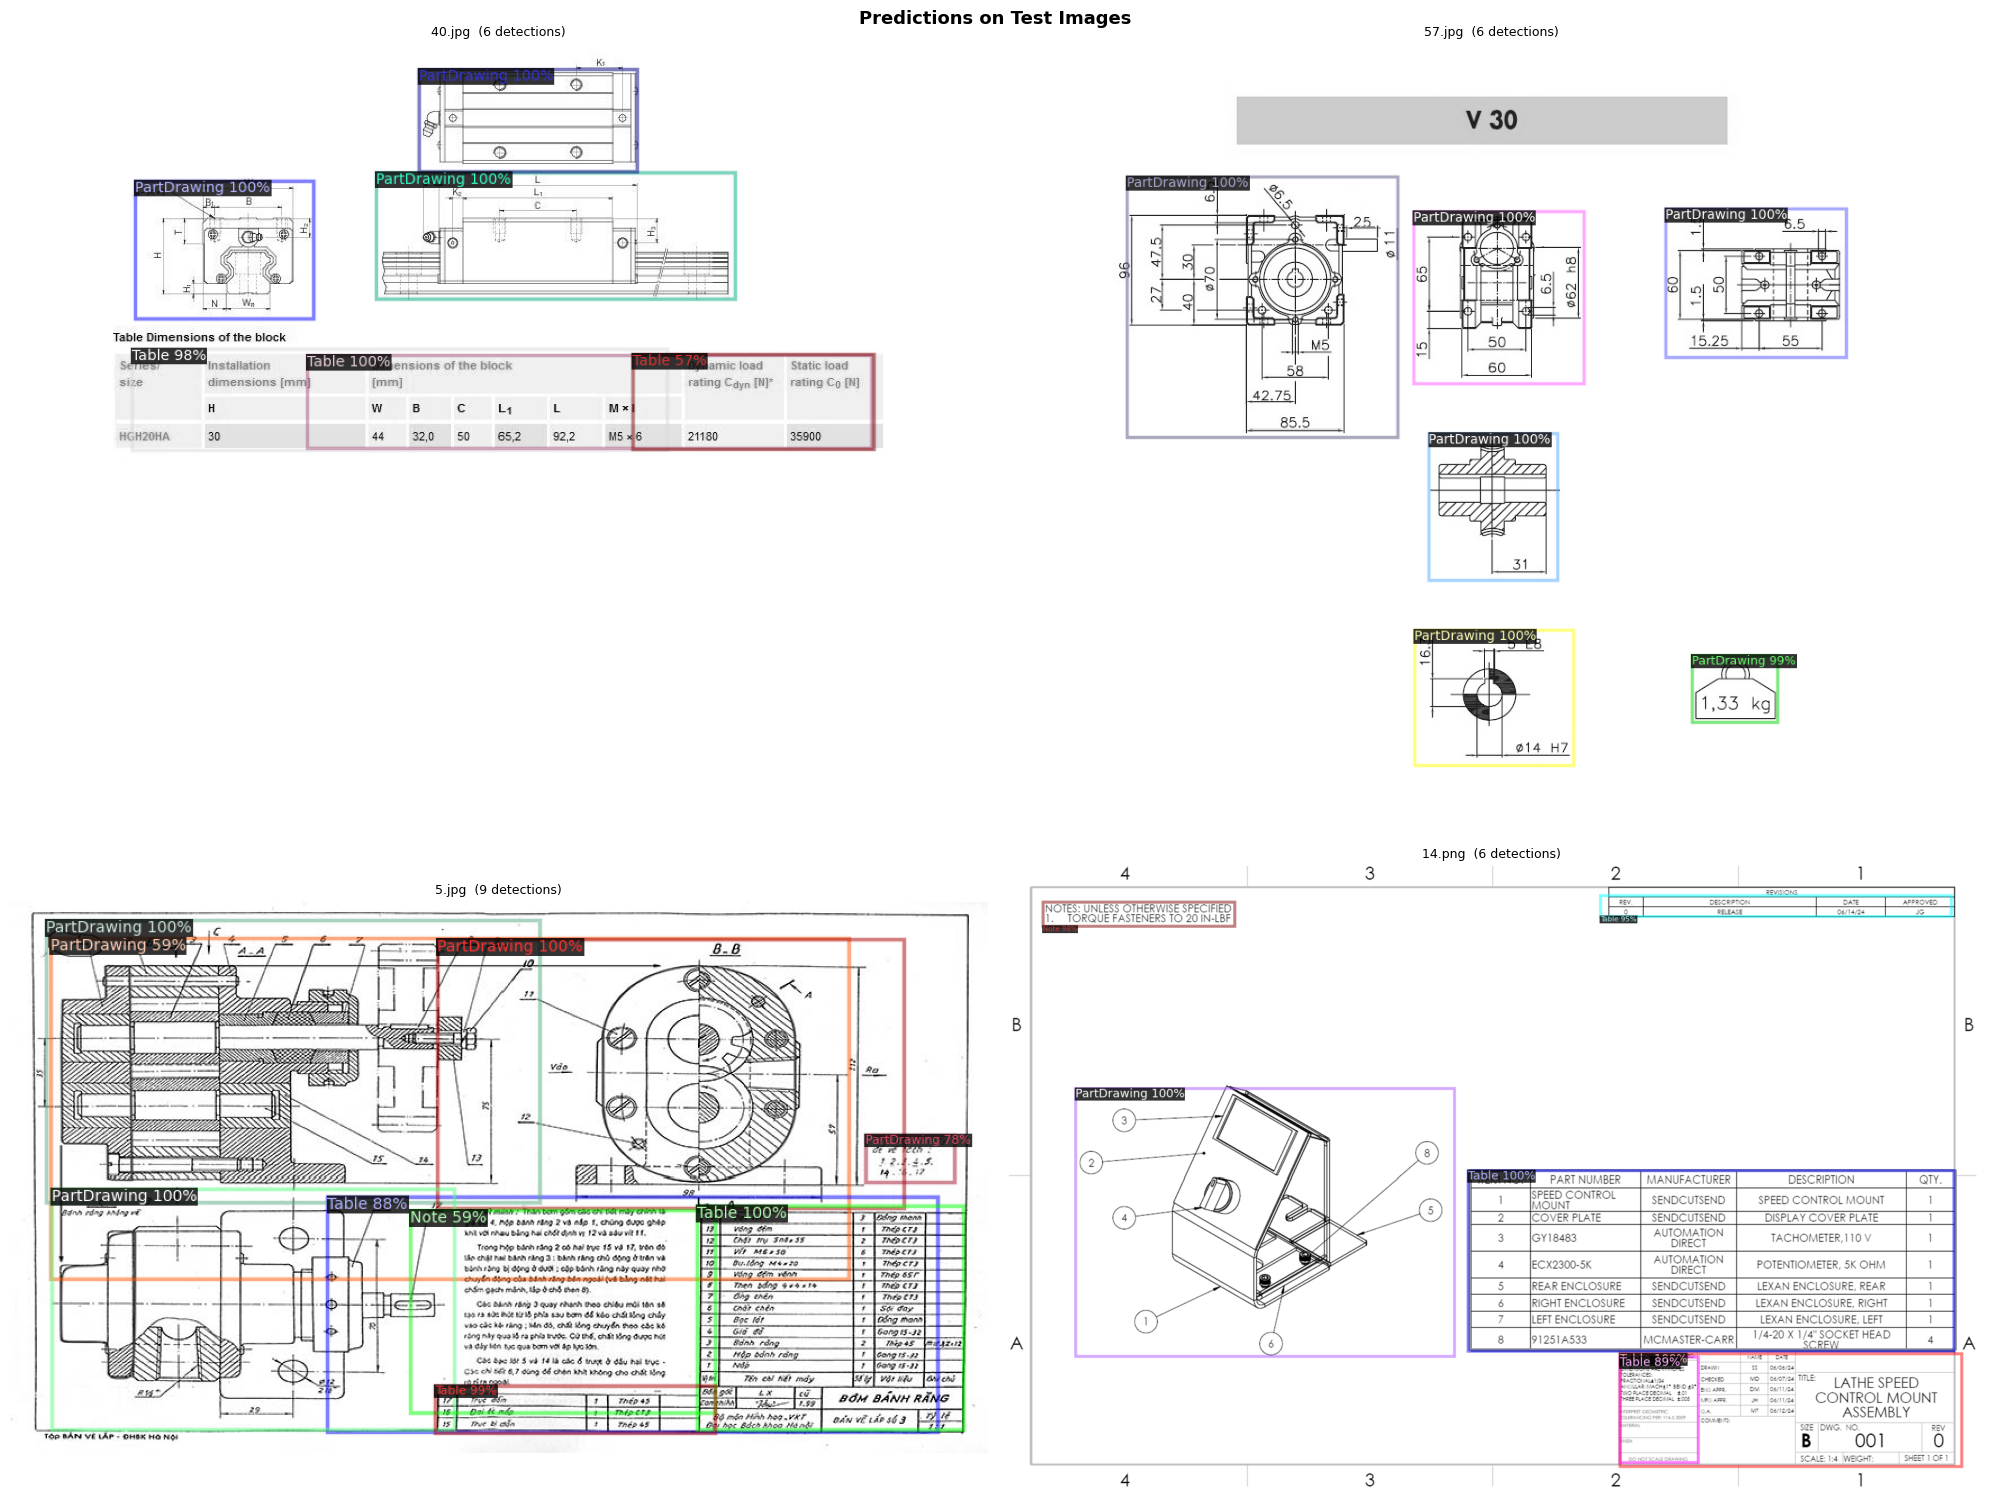

Saved: test_predictions.png


In [ ]:
def visualize_predictions(predictor, records, n=4):
    samples  = random.sample(records, min(n, len(records)))
    metadata = MetadataCatalog.get('bom_test')

    cols = min(n, 2)
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(10 * cols, 8 * rows))
    axes = np.array(axes).flatten() if rows * cols > 1 else [axes]

    for ax, rec in zip(axes, samples):
        img_bgr = cv2.imread(rec['file_name'])
        outputs = predictor(img_bgr)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        v   = Visualizer(img_rgb, metadata=metadata, scale=1.0,
                         instance_mode=ColorMode.IMAGE_BW)
        out = v.draw_instance_predictions(outputs['instances'].to('cpu'))

        ax.imshow(out.get_image())
        n_det = len(outputs['instances'])
        ax.set_title(f"{os.path.basename(rec['file_name'])}  ({n_det} detections)",
                     fontsize=9)
        ax.axis('off')

    # Ẩn axes thừa
    for ax in axes[len(samples):]:
        ax.set_visible(False)

    plt.suptitle('Predictions on Test Images', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'test_predictions.png'), dpi=100)
    plt.show()
    print('Saved: test_predictions.png')


visualize_predictions(predictor, test_records, n=4)

In [ ]:
import os
import json
import cv2
import shutil
from pathlib import Path

# Tạo thư mục tổng hợp kết quả đầu ra
FINAL_OUT_DIR = os.path.join(WORK_DIR, 'result_output')
os.makedirs(FINAL_OUT_DIR, exist_ok=True)

# 1. Copy weight của model tối ưu nhất vào thư mục result_output
best_model_path = os.path.join(OUTPUT_DIR, 'model_final.pth')
if os.path.exists(best_model_path):
    shutil.copy(best_model_path, os.path.join(FINAL_OUT_DIR, 'model_final.pth'))
    print(f"Đã copy model weights vào thư mục {FINAL_OUT_DIR}")

# 2. Tạo các thư mục con tương ứng chứa ảnh crop
for cls_name in CLASS_NAMES:
    os.makedirs(os.path.join(FINAL_OUT_DIR, cls_name), exist_ok=True)

def check_ioa(box1, box2):
    # Trả về tỷ lệ lồng nhau lớn nhất dựa trên diện tích của từng vùng
    x11, y11, x21, y21 = box1
    x12, y12, x22, y22 = box2
    
    ix1 = max(x11, x12)
    iy1 = max(y11, y12)
    ix2 = min(x21, x22)
    iy2 = min(y21, y22)
    
    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)
    inter_area = iw * ih
    
    area1 = max(0, x21 - x11) * max(0, y21 - y11)
    area2 = max(0, x22 - x12) * max(0, y22 - y12)
    
    if inter_area == 0:
        return 0.0, area1, area2
        
    ioa1 = inter_area / area1 if area1 > 0 else 0
    ioa2 = inter_area / area2 if area2 > 0 else 0
    
    return max(ioa1, ioa2), area1, area2

def process_and_export(predictor, records):
    metadata = MetadataCatalog.get('bom_test')
    classes = metadata.thing_classes
    
    for rec in records:
        img_path = rec['file_name']
        img_name = os.path.basename(img_path)
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            continue
            
        outputs = predictor(img_bgr)
        instances = outputs["instances"].to("cpu")
        
        boxes = instances.pred_boxes.tensor.numpy()
        scores = instances.scores.numpy()
        pred_classes = instances.pred_classes.numpy()
        
        # Tiền xử lý: Lọc các table bị lồng nhau > 50%
        table_indices = []
        keep_indices = []
        for i in range(len(boxes)):
            if classes[pred_classes[i]] == 'Table':
                table_indices.append(i)
            else:
                keep_indices.append(i)
                
        tables_to_keep = set(table_indices)
        for i in range(len(table_indices)):
            for j in range(i + 1, len(table_indices)):
                idx1 = table_indices[i]
                idx2 = table_indices[j]
                if idx1 not in tables_to_keep or idx2 not in tables_to_keep:
                    continue
                    
                overlap_ratio, area1, area2 = check_ioa(boxes[idx1], boxes[idx2])
                if overlap_ratio > 0.5:
                    if area1 >= area2:
                        tables_to_keep.discard(idx2)
                    else:
                        tables_to_keep.discard(idx1)
                        
        keep_indices.extend(list(tables_to_keep))
        keep_indices = sorted(keep_indices)
        
        json_data = {
            "image": img_name,
            "objects": []
        }
        
        obj_id = 1
        for i in keep_indices:
            box = boxes[i]
            score = float(scores[i])
            cls_idx = pred_classes[i]
            cls_name = classes[cls_idx]
            
            x1, y1, x2, y2 = map(int, box)
            
            # Lưu lại thông tin vào danh sách object
            obj_info = {
                "id": obj_id,
                "class": cls_name,
                "confidence": round(score, 2),
                "bbox": {"x1": x1, "y1": y1, "x2": x2, "y2": y2},
                "ocr_content": "..."
            }
            json_data["objects"].append(obj_info)
            
            # Crop từng đối tượng detected thành ảnh con riêng biệt
            h, w = img_bgr.shape[:2]
            x1_c = max(0, x1)
            y1_c = max(0, y1)
            x2_c = min(w, x2)
            y2_c = min(h, y2)
            
            if x1_c >= x2_c or y1_c >= y2_c:
                continue
                
            crop_img = img_bgr[y1_c:y2_c, x1_c:x2_c]
            
            # Lưu file ảnh con vào folder của class tương ứng (Note, Table, PartDrawing)
            crop_filename = f"{os.path.splitext(img_name)[0]}_{cls_name}_{obj_id}.jpg"
            crop_path = os.path.join(FINAL_OUT_DIR, cls_name, crop_filename)
            cv2.imwrite(crop_path, crop_img)
            
            obj_id += 1
            
        # 3. Xuất JSON chứa thông tin toạ độ, class, confidence của từng đối tượng
        json_filename = f"{os.path.splitext(img_name)[0]}_results.json"
        json_path = os.path.join(FINAL_OUT_DIR, json_filename)
        with open(json_path, 'w', encoding='utf-8') as f:
            json.dump(json_data, f, ensure_ascii=False, indent=2)
            
    print(f"Hoàn thành trích xuất. Toàn bộ kết quả JSON, ảnh crop và Model Weight được lưu tại: {FINAL_OUT_DIR}")

# Thực thi trích xuất trên toàn bộ tập test
print("Đang xử lý")
process_and_export(predictor, test_records)

Đã copy model weights vào thư mục /kaggle/working/result_output
Đang xử lý
Hoàn thành trích xuất. Toàn bộ kết quả JSON, ảnh crop và Model Weight được lưu tại: /kaggle/working/result_output
